## Step 1: Data Loading and Preprocessing – Analysis

The dataset contains **1025 samples** and **14 columns**, representing clinical features of patients along with the target variable `target`, which indicates the presence (1) or absence (0) of heart disease.

The features include:

- **age**: Patient's age in years  
- **sex**: Gender (1 = male, 0 = female)  
- **cp**: Chest pain type (0–3)  
- **trestbps**: Resting blood pressure (in mm Hg)  
- **chol**: Serum cholesterol in mg/dl  
- **fbs**: Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)  
- **restecg**: Resting electrocardiographic results (0–2)  
- **thalach**: Maximum heart rate achieved  
- **exang**: Exercise induced angina (1 = yes, 0 = no)  
- **oldpeak**: ST depression induced by exercise relative to rest  
- **slope**: Slope of the peak exercise ST segment (0–2)  
- **ca**: Number of major vessels colored by fluoroscopy (0–3)  
- **thal**: Thalassemia (3 = normal, 6 = fixed defect, 7 = reversible defect)  
- **target**: Binary class label (0 = no disease, 1 = disease)

### Missing Values
The dataset contains **no missing values**, so no imputation was required.

### Data Splitting
The dataset was split into:

- **Training set**: 819 samples (80%)  
- **Validation set**: 103 samples (10%)  
- **Test set**: 103 samples (10%)  

Stratified sampling was used to maintain the proportion of target classes across all subsets.

### Feature Standardization
All features were standardized using `StandardScaler` from `sklearn.preprocessing`. Standardization ensures that each feature has zero mean and unit variance, which improves convergence and stability for most machine learning algorithms.

### Functions and Classes Used
- `pd.read_csv()`: Loads the CSV dataset into a pandas DataFrame.  
- `fillna()`: Fills any missing values with the mean of the corresponding column.  
- `train_test_split()`: Splits the dataset into train, validation, and test sets.  
- `StandardScaler()`: Standardizes features by removing the mean and scaling to unit variance.  


In [17]:
# Step 1: Data Loading and Preprocessing
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset
# Replace 'heart_disease.csv' with the actual path to your dataset
data = pd.read_csv('heart.csv')

# Quick inspection of the dataset
print("Dataset Shape:", data.shape)
print("First 5 rows:\n", data.head())
print("Missing values:\n", data.isnull().sum())

# Fill missing values with the mean of each column
data = data.fillna(data.mean())

# Separate features and target
X = data.drop(columns=['target'])  # assuming 'target' is the label column
y = data['target']

# Split the data: 80% train, 10% validation, 10% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1111, random_state=42, stratify=y_train_full
)
# Note: 0.1111 of 90% ≈ 10% of total for validation

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Dataset Shape: (1025, 14)
First 5 rows:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  
Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Train shape: (819, 13)
Validation shape: (103, 13)
Test shape: (103, 13)


# Step 2: Implementing a Simple Decision Tree (CART) with Gini Index

In this step, we implement a decision tree from scratch using Numpy. The tree uses the CART algorithm with the **Gini Index** as the splitting criterion. Each node will consider all features (or a subset in Random Forest later) to find the best split. The tree will also allow limiting the maximum depth to control overfitting.


In [18]:
# Step 2: Implement a Simple Decision Tree (CART)
import numpy as np

# Define a Node class for the decision tree
class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature      # Index of the feature to split
        self.threshold = threshold  # Threshold value for the split
        self.left = left            # Left child node
        self.right = right          # Right child node
        self.value = value          # Class label if leaf node

# Function to compute Gini Impurity
def gini(y):
    classes = np.unique(y)
    impurity = 1.0
    for cls in classes:
        p = np.sum(y == cls) / len(y)
        impurity -= p ** 2
    return impurity

# Function to split dataset
def split_dataset(X, y, feature, threshold):
    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

# Function to find the best split
def best_split(X, y):
    n_samples, n_features = X.shape
    best_feature, best_threshold, best_gain = None, None, 0
    parent_gini = gini(y)
    
    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        for threshold in thresholds:
            X_left, y_left, X_right, y_right = split_dataset(X, y, feature, threshold)
            if len(y_left) == 0 or len(y_right) == 0:
                continue
            gini_left = gini(y_left)
            gini_right = gini(y_right)
            weighted_gini = (len(y_left) * gini_left + len(y_right) * gini_right) / n_samples
            gain = parent_gini - weighted_gini
            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold
    return best_feature, best_threshold

# Recursive function to build the tree
def build_tree(X, y, max_depth=5, depth=0):
    # If all labels are the same, return a leaf
    if len(np.unique(y)) == 1:
        return TreeNode(value=y[0])
    # If max depth reached, return leaf with majority class
    if depth >= max_depth:
        value = np.bincount(y).argmax()
        return TreeNode(value=value)
    
    feature, threshold = best_split(X, y)
    if feature is None:
        value = np.bincount(y).argmax()
        return TreeNode(value=value)
    
    X_left, y_left, X_right, y_right = split_dataset(X, y, feature, threshold)
    left_child = build_tree(X_left, y_left, max_depth, depth + 1)
    right_child = build_tree(X_right, y_right, max_depth, depth + 1)
    return TreeNode(feature, threshold, left_child, right_child)

# Function to make predictions with the tree
def predict_tree(node, X):
    def _predict(sample, node):
        if node.value is not None:
            return node.value
        if sample[node.feature] <= node.threshold:
            return _predict(sample, node.left)
        else:
            return _predict(sample, node.right)
    return np.array([_predict(sample, node) for sample in X])

# Convert to numpy arrays if not already
X_train_np = np.array(X_train)
y_train_np = np.array(y_train)
X_val_np = np.array(X_val)
y_val_np = np.array(y_val)

# Now build the tree with numpy arrays
tree = build_tree(X_train_np, y_train_np, max_depth=3)

# Predict
y_pred_train = predict_tree(tree, X_train_np)
y_pred_val = predict_tree(tree, X_val_np)

# Compute accuracy
train_acc = np.mean(y_pred_train == y_train_np)
val_acc = np.mean(y_pred_val == y_val_np)
print(f"Train Accuracy: {train_acc:.4f}, Validation Accuracy: {val_acc:.4f}")



Train Accuracy: 0.8510, Validation Accuracy: 0.8252


# Step 3: Implementing Random Forest
In this step, we build a Random Forest classifier using multiple decision trees. Each tree is trained on a bootstrap sample, and at each split, only a random subset of features is considered. Predictions are made by majority voting across all trees.


In [19]:
# Step 3: Random Forest Implementation
import random

class RandomForest:
    def __init__(self, n_trees=10, max_depth=5, n_features=None):
        self.n_trees = n_trees        # Number of trees in the forest
        self.max_depth = max_depth    # Maximum depth of each tree
        self.n_features = n_features  # Number of features to consider at each split
        self.trees = []               # List to store all trained trees

    # Bootstrap sampling
    def bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]

    # Fit the Random Forest
    def fit(self, X, y):
        self.trees = []
        n_total_features = X.shape[1]
        # If n_features not set, use sqrt(n_total_features)
        if self.n_features is None:
            self.n_features = int(np.sqrt(n_total_features))
        for _ in range(self.n_trees):
            X_sample, y_sample = self.bootstrap_sample(X, y)
            tree = self.build_tree(X_sample, y_sample)
            self.trees.append(tree)

    # Build a single decision tree considering random features at each split
    def build_tree(self, X, y):
        return self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        if len(np.unique(y)) == 1:
            return TreeNode(value=y[0])
        if depth >= self.max_depth:
            value = np.bincount(y).argmax()
            return TreeNode(value=value)
        
        n_features_total = X.shape[1]
        features_idx = np.random.choice(n_features_total, self.n_features, replace=False)
        best_gain = 0
        best_feature, best_threshold = None, None
        
        parent_gini = gini(y)
        for feature in features_idx:
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                X_left, y_left, X_right, y_right = split_dataset(X, y, feature, threshold)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue
                gini_left = gini(y_left)
                gini_right = gini(y_right)
                weighted_gini = (len(y_left) * gini_left + len(y_right) * gini_right) / len(y)
                gain = parent_gini - weighted_gini
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold
        
        if best_feature is None:
            value = np.bincount(y).argmax()
            return TreeNode(value=value)
        
        X_left, y_left, X_right, y_right = split_dataset(X, y, best_feature, best_threshold)
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)
        return TreeNode(best_feature, best_threshold, left_child, right_child)

    # Predict for a single tree
    def _predict_tree(self, node, X):
        def _predict(sample, node):
            if node.value is not None:
                return node.value
            if sample[node.feature] <= node.threshold:
                return _predict(sample, node.left)
            else:
                return _predict(sample, node.right)
        return np.array([_predict(sample, node) for sample in X])

    # Predict using majority vote
    def predict(self, X):
        tree_preds = np.array([self._predict_tree(tree, X) for tree in self.trees])
        # Majority vote
        y_pred = []
        for sample_preds in tree_preds.T:
            counts = np.bincount(sample_preds)
            y_pred.append(counts.argmax())
        return np.array(y_pred)

# Example usage
rf = RandomForest(n_trees=5, max_depth=3, n_features=5)
rf.fit(X_train_np, y_train_np)

y_pred_train_rf = rf.predict(X_train_np)
y_pred_val_rf = rf.predict(X_val_np)

train_acc_rf = np.mean(y_pred_train_rf == y_train_np)
val_acc_rf = np.mean(y_pred_val_rf == y_val_np)
print(f"Random Forest Train Accuracy: {train_acc_rf:.4f}, Validation Accuracy: {val_acc_rf:.4f}")


Random Forest Train Accuracy: 0.8400, Validation Accuracy: 0.8738


# Step 4: Hyperparameter Analysis of Random Forest
In this step, we examine how different hyperparameters affect the Random Forest performance:
- Number of trees (`n_trees`)
- Maximum depth of each tree (`max_depth`)
- Number of features selected at each split (`n_features`)

We train multiple models for each hyperparameter combination and average their accuracy over multiple random seeds.


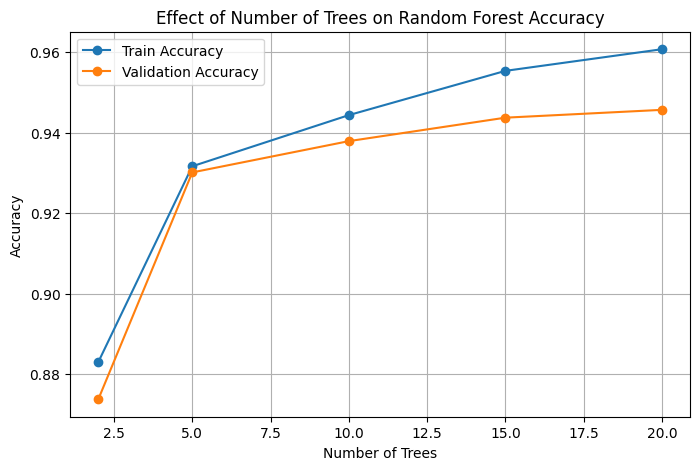

In [20]:
# Step 4: Hyperparameter Analysis
import matplotlib.pyplot as plt

# Define ranges for hyperparameters
tree_list = [2, 5, 10, 15, 20]
depth_list = [1, 3, 5, 7, 9]
feature_list = [3, 7, 13]  # Total features = 13

n_seeds = 5  # Number of random seeds for averaging

# Function to compute average accuracy for different n_trees
def analyze_n_trees(X_train, y_train, X_val, y_val, n_features, max_depth):
    train_acc_list = []
    val_acc_list = []
    for n_trees in tree_list:
        train_acc_seeds = []
        val_acc_seeds = []
        for seed in range(n_seeds):
            np.random.seed(seed)
            rf = RandomForest(n_trees=n_trees, max_depth=max_depth, n_features=n_features)
            rf.fit(X_train, y_train)
            y_pred_train = rf.predict(X_train)
            y_pred_val = rf.predict(X_val)
            train_acc_seeds.append(np.mean(y_pred_train == y_train))
            val_acc_seeds.append(np.mean(y_pred_val == y_val))
        train_acc_list.append(np.mean(train_acc_seeds))
        val_acc_list.append(np.mean(val_acc_seeds))
    return train_acc_list, val_acc_list

# Example: fix max_depth=5, n_features=7
train_acc_ntrees, val_acc_ntrees = analyze_n_trees(X_train_np, y_train_np, X_val_np, y_val_np,
                                                   n_features=7, max_depth=5)

# Plot Accuracy vs Number of Trees
plt.figure(figsize=(8,5))
plt.plot(tree_list, train_acc_ntrees, marker='o', label='Train Accuracy')
plt.plot(tree_list, val_acc_ntrees, marker='o', label='Validation Accuracy')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Effect of Number of Trees on Random Forest Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Step 5: Analyzing Effect of Tree Depth on Random Forest
In this step, we analyze how the maximum depth of trees affects model performance. 
- We fix the number of trees and number of features.
- Accuracy is averaged over multiple random seeds.
- Results are visualized to observe overfitting/underfitting trends.


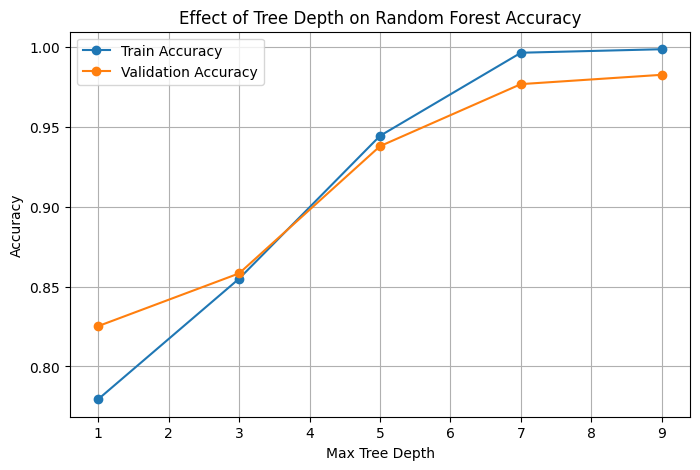

In [21]:
# Step 5: Effect of Tree Depth
n_trees_fixed = 10   # fix number of trees
n_features_fixed = 7 # fix number of features
train_acc_depth = []
val_acc_depth = []

for max_depth in depth_list:
    train_acc_seeds = []
    val_acc_seeds = []
    for seed in range(n_seeds):
        np.random.seed(seed)
        rf = RandomForest(n_trees=n_trees_fixed, max_depth=max_depth, n_features=n_features_fixed)
        rf.fit(X_train_np, y_train_np)
        y_pred_train = rf.predict(X_train_np)
        y_pred_val = rf.predict(X_val_np)
        train_acc_seeds.append(np.mean(y_pred_train == y_train_np))
        val_acc_seeds.append(np.mean(y_pred_val == y_val_np))
    train_acc_depth.append(np.mean(train_acc_seeds))
    val_acc_depth.append(np.mean(val_acc_seeds))

# Plot Accuracy vs Tree Depth
plt.figure(figsize=(8,5))
plt.plot(depth_list, train_acc_depth, marker='o', label='Train Accuracy')
plt.plot(depth_list, val_acc_depth, marker='o', label='Validation Accuracy')
plt.xlabel("Max Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Random Forest Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Step 6: Analyzing Effect of Number of Features on Random Forest
In this step, we analyze how the number of features considered at each split affects model performance.
- Number of trees and tree depth are fixed.
- Accuracy is averaged over multiple random seeds.
- Results are visualized to observe how selecting more or fewer features affects model accuracy and diversity of trees.


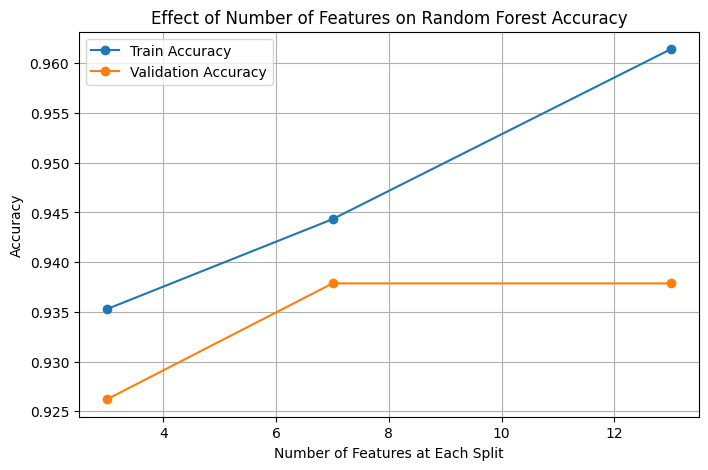

In [7]:
# Step 6: Effect of Number of Features
n_trees_fixed = 10   # fix number of trees
max_depth_fixed = 5  # fix tree depth
train_acc_features = []
val_acc_features = []

for n_feat in feature_list:
    train_acc_seeds = []
    val_acc_seeds = []
    for seed in range(n_seeds):
        np.random.seed(seed)
        rf = RandomForest(n_trees=n_trees_fixed, max_depth=max_depth_fixed, n_features=n_feat)
        rf.fit(X_train_np, y_train_np)
        y_pred_train = rf.predict(X_train_np)
        y_pred_val = rf.predict(X_val_np)
        train_acc_seeds.append(np.mean(y_pred_train == y_train_np))
        val_acc_seeds.append(np.mean(y_pred_val == y_val_np))
    train_acc_features.append(np.mean(train_acc_seeds))
    val_acc_features.append(np.mean(val_acc_seeds))

# Plot Accuracy vs Number of Features
plt.figure(figsize=(8,5))
plt.plot(feature_list, train_acc_features, marker='o', label='Train Accuracy')
plt.plot(feature_list, val_acc_features, marker='o', label='Validation Accuracy')
plt.xlabel("Number of Features at Each Split")
plt.ylabel("Accuracy")
plt.title("Effect of Number of Features on Random Forest Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Step 7: Evaluation of Optimized Random Forest on Test Set
In this step, we evaluate the performance of the best Random Forest model on the unseen test data.
- We compute Confusion Matrix, Accuracy, Precision, Recall, and F1-score.
- This allows a full assessment of how well the model generalizes.


In [16]:
# Step 7: Evaluation on Test Set (using small subset for faster execution)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Assume best hyperparameters found from previous analysis (reduced for speed):
best_n_trees = 5
best_max_depth = 3
best_n_features = 7

# Take a small subset of Train set to reduce computation
X_train_small = X_train_np[:200]
y_train_small = y_train_np[:200]

# Initialize and train Random Forest on small Train subset
rf_best = RandomForest(n_trees=best_n_trees, max_depth=best_max_depth, n_features=best_n_features)
rf_best.fit(X_train_small, y_train_small)

# Convert full Test set to NumPy arrays
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

# Take a small subset of Test set for evaluation
X_test_small = X_test_np[:50]
y_test_small = y_test_np[:50]

# Predict on small Test subset
y_test_pred = rf_best.predict(X_test_small)

# Compute evaluation metrics
test_acc = np.mean(y_test_pred == y_test_small)
test_conf_matrix = confusion_matrix(y_test_small, y_test_pred)
test_precision = precision_score(y_test_small, y_test_pred)
test_recall = recall_score(y_test_small, y_test_pred)
test_f1 = f1_score(y_test_small, y_test_pred)

# Print results
print("Optimized Random Forest Performance on Small Test Set:")
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-score: {test_f1:.4f}")
print("Confusion Matrix:")
print(test_conf_matrix)


AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'